<a href="https://colab.research.google.com/github/swaroopchandran015-arch/AIML-Lab/blob/main/AILAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zoya77/cloud-workload-dataset-for-scheduling-analysis")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cloud-workload-dataset-for-scheduling-analysis' dataset.
Path to dataset files: /kaggle/input/cloud-workload-dataset-for-scheduling-analysis


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [51]:
# Install kagglehub if needed
!pip install -q kagglehub

import kagglehub
import pandas as pd
import os

# Download the dataset
path = kagglehub.dataset_download(
    "zoya77/cloud-workload-dataset-for-scheduling-analysis"
)

print("Dataset path:", path)

# List the files in the downloaded folder
print(os.listdir(path))


Using Colab cache for faster access to the 'cloud-workload-dataset-for-scheduling-analysis' dataset.
Dataset path: /kaggle/input/cloud-workload-dataset-for-scheduling-analysis
['cloud_workload_dataset.csv']


In [53]:
df = pd.read_csv(os.path.join(path, "cloud_workload_dataset.csv"))

# Display the first few rows
df.head()


,Job_ID,Task_Start_Time,Task_End_Time,CPU_Utilization (%),Memory_Consumption (MB),Task_Execution_Time (ms),System_Throughput (tasks/sec),Task_Waiting_Time (ms),Data_Source,Number_of_Active_Users,Network_Bandwidth_Utilization (Mbps),Job_Priority,Scheduler_Type,Resource_Allocation_Type,Error_Rate (%)
0,JOB_1,2024-01-01 00:00:00,2024-01-01 00:00:00,39.96,3622,2734,9.03,83,IoT,3000,112.97,Low,FCFS,Static,1.65
1,JOB_2,2024-01-01 00:01:00,2024-01-01 00:01:00,86.06,5690,2868,8.03,64,Social Media,4590,329.20,Low,Priority-Based,Dynamic,2.92
2,JOB_3,2024-01-01 00:02:00,2024-01-01 00:02:00,68.56,5075,1311,5.69,971,Cloud,3780,542.82,Low,Priority-Based,Static,2.60
3,JOB_4,2024-01-01 00:03:00,2024-01-01 00:03:00,57.89,7686,875,4.51,757,Social Media,4474,973.94,Medium,Priority-Based,Dynamic,1.33
4,JOB_5,2024-01-01 00:04:00,2024-01-01 00:04:00,22.48,2297,1260,6.38,581,Enterprise DB,1981,405.38,Low,FCFS,Static,1.99


In [54]:
df.info()

# Dataset shape

print("Shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Job_ID                                5000 non-null   object 
 1   Task_Start_Time                       5000 non-null   object 
 2   Task_End_Time                         5000 non-null   object 
 3   CPU_Utilization (%)                   5000 non-null   float64
 4   Memory_Consumption (MB)               5000 non-null   int64  
 5   Task_Execution_Time (ms)              5000 non-null   int64  
 6   System_Throughput (tasks/sec)         5000 non-null   float64
 7   Task_Waiting_Time (ms)                5000 non-null   int64  
 8   Data_Source                           5000 non-null   object 
 9   Number_of_Active_Users                5000 non-null   int64  
 10  Network_Bandwidth_Utilization (Mbps)  5000 non-null   float64
 11  Job_Priority     

In [55]:
# Number of rows and columns

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Data types

print(df.dtypes)

# Missing values

print(df.isnull().sum())

Rows: 5000
Columns: 15
Job_ID                                   object
Task_Start_Time                          object
Task_End_Time                            object
CPU_Utilization (%)                     float64
Memory_Consumption (MB)                   int64
Task_Execution_Time (ms)                  int64
System_Throughput (tasks/sec)           float64
Task_Waiting_Time (ms)                    int64
Data_Source                              object
Number_of_Active_Users                    int64
Network_Bandwidth_Utilization (Mbps)    float64
Job_Priority                             object
Scheduler_Type                           object
Resource_Allocation_Type                 object
Error_Rate (%)                          float64
dtype: object
Job_ID                                  0
Task_Start_Time                         0
Task_End_Time                           0
CPU_Utilization (%)                     0
Memory_Consumption (MB)                 0
Task_Execution_Time (ms)         

In [56]:
# First 5 rows

df.head()

# Last 5 rows

df.tail()

# Random 5 rows

df.sample(5)

,Job_ID,Task_Start_Time,Task_End_Time,CPU_Utilization (%),Memory_Consumption (MB),Task_Execution_Time (ms),System_Throughput (tasks/sec),Task_Waiting_Time (ms),Data_Source,Number_of_Active_Users,Network_Bandwidth_Utilization (Mbps),Job_Priority,Scheduler_Type,Resource_Allocation_Type,Error_Rate (%)
1967,JOB_1968,2024-01-02 08:47:00,2024-01-02 08:47:00,38.98,4939,1026,6.68,448,Enterprise DB,971,569.34,Medium,Round Robin,Dynamic,1.29
2788,JOB_2789,2024-01-02 22:28:00,2024-01-02 22:28:00,86.11,5909,4469,5.17,195,IoT,4911,563.14,High,Round Robin,Dynamic,2.87
338,JOB_339,2024-01-01 05:38:00,2024-01-01 05:38:00,47.93,4265,1364,3.42,815,Cloud,455,282.80,Low,Priority-Based,Static,3.40
900,JOB_901,2024-01-01 15:00:00,2024-01-01 15:00:00,26.63,992,2624,1.83,925,Enterprise DB,2857,399.82,Medium,FCFS,Dynamic,2.79
4939,JOB_4940,2024-01-04 10:19:00,2024-01-04 10:19:00,74.94,6612,4981,3.19,390,IoT,3065,967.50,Low,FCFS,Dynamic,2.92


In [57]:
df.isnull().sum()

,0
Job_ID,0
Task_Start_Time,0
Task_End_Time,0
CPU_Utilization (%),0
Memory_Consumption (MB),0
Task_Execution_Time (ms),0
System_Throughput (tasks/sec),0
Task_Waiting_Time (ms),0
Data_Source,0
Number_of_Active_Users,0


In [58]:
# Replace missing numerical values with mean

df.fillna(df.mean(numeric_only=True), inplace=True)

In [59]:
# Replace missing categorical values with mode

for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_2614/2081751939.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [60]:
print("Duplicate rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

Duplicate rows: 0


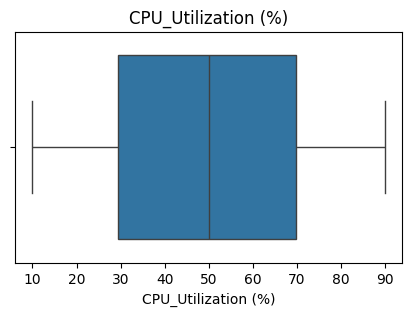

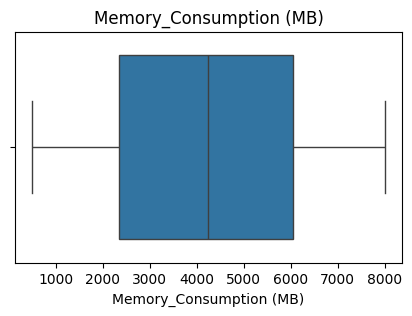

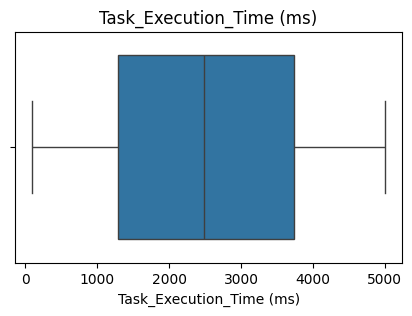

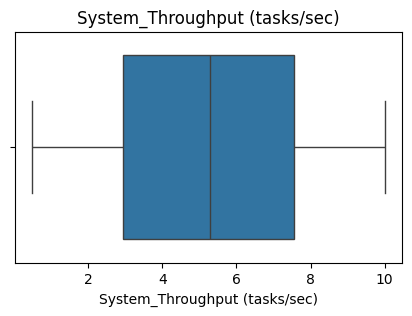

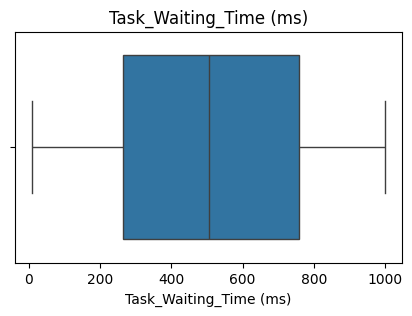

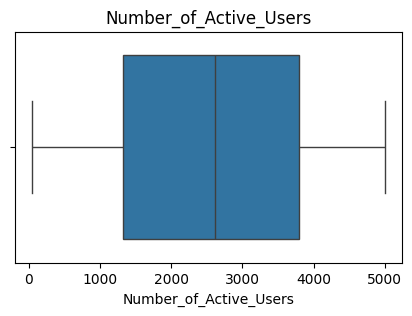

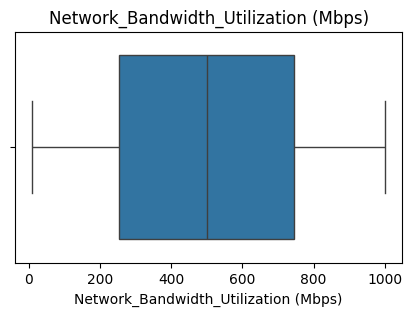

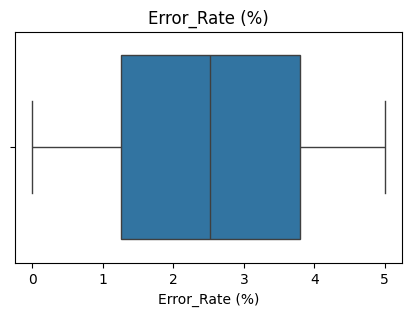

In [61]:
# Select numerical columns

num_cols = df.select_dtypes(include=np.number)

# Draw boxplots

for col in num_cols.columns:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [63]:
# Remove outliers using IQR

for col in num_cols.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [64]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

df.head()

,Job_ID,Task_Start_Time,Task_End_Time,CPU_Utilization (%),Memory_Consumption (MB),Task_Execution_Time (ms),System_Throughput (tasks/sec),Task_Waiting_Time (ms),Data_Source,Number_of_Active_Users,Network_Bandwidth_Utilization (Mbps),Job_Priority,Scheduler_Type,Resource_Allocation_Type,Error_Rate (%)
0,0,0,0,39.96,3622,2734,9.03,83,2,3000,112.97,1,1,1,1.65
1,1111,1,1,86.06,5690,2868,8.03,64,3,4590,329.20,1,2,0,2.92
2,2222,2,2,68.56,5075,1311,5.69,971,0,3780,542.82,1,2,1,2.60
3,3333,3,3,57.89,7686,875,4.51,757,3,4474,973.94,2,2,0,1.33
4,4444,4,4,22.48,2297,1260,6.38,581,1,1981,405.38,1,1,1,1.99


In [65]:
df = pd.get_dummies(df, drop_first=True)

In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[df.columns] = scaler.fit_transform(df)

In [68]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[df.columns] = scaler.fit_transform(df)

In [69]:
correlation = df.corr()

print(correlation)

                                        Job_ID  Task_Start_Time  \
Job_ID                                1.000000         0.335634   
Task_Start_Time                       0.335634         1.000000   
Task_End_Time                         0.335634         1.000000   
CPU_Utilization (%)                  -0.021524        -0.005801   
Memory_Consumption (MB)               0.013053         0.007970   
Task_Execution_Time (ms)              0.005937         0.010296   
System_Throughput (tasks/sec)        -0.006205         0.000628   
Task_Waiting_Time (ms)               -0.009256         0.006812   
Data_Source                           0.037014         0.005014   
Number_of_Active_Users                0.002966         0.014792   
Network_Bandwidth_Utilization (Mbps)  0.034566         0.013718   
Job_Priority                          0.005486         0.012048   
Scheduler_Type                        0.009506        -0.020400   
Resource_Allocation_Type             -0.008581        -0.02536

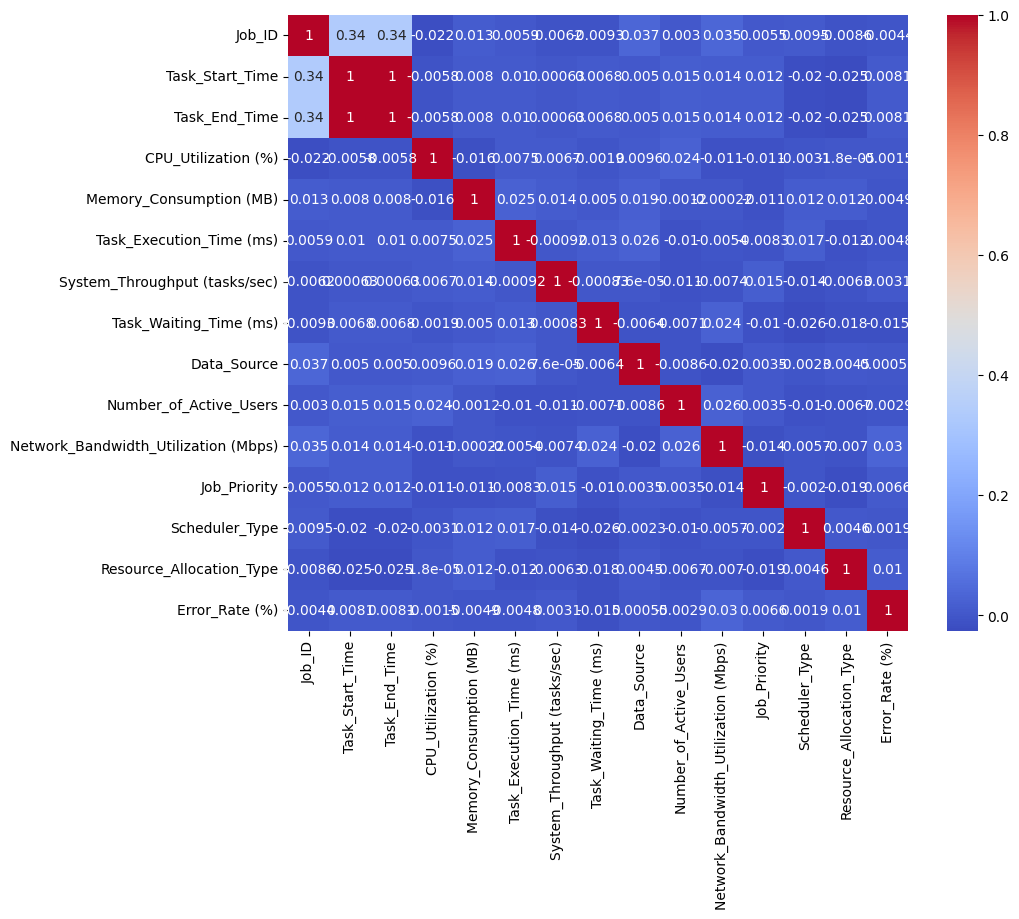

In [70]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.show()

In [71]:
# Create a new feature by adding two numerical columns

df["New_Feature"] = df.iloc[:,0] + df.iloc[:,1]

df.head()

,Job_ID,Task_Start_Time,Task_End_Time,CPU_Utilization (%),Memory_Consumption (MB),Task_Execution_Time (ms),System_Throughput (tasks/sec),Task_Waiting_Time (ms),Data_Source,Number_of_Active_Users,Network_Bandwidth_Utilization (Mbps),Job_Priority,Scheduler_Type,Resource_Allocation_Type,Error_Rate (%),New_Feature
0,0.000000,0.0000,0.0000,0.374594,0.416222,0.537472,0.897895,0.073812,0.666667,0.596200,0.103975,0.5,0.333333,1.0,0.330,0.000000
1,0.222244,0.0002,0.0002,0.950988,0.692102,0.564836,0.792632,0.054601,1.000000,0.917542,0.322464,0.5,0.666667,0.0,0.584,0.222444
2,0.444489,0.0004,0.0004,0.732183,0.610059,0.246886,0.546316,0.971689,0.000000,0.753840,0.538316,0.5,0.666667,1.0,0.520,0.444889
3,0.666733,0.0006,0.0006,0.598775,0.958378,0.157852,0.422105,0.755308,1.000000,0.894099,0.973941,1.0,0.666667,0.0,0.266,0.667333
4,0.888978,0.0008,0.0008,0.156039,0.239461,0.236471,0.618947,0.577351,0.333333,0.390259,0.399440,0.5,0.333333,1.0,0.398,0.889778


In [72]:
print(df.dtypes)

Job_ID                                  float64
Task_Start_Time                         float64
Task_End_Time                           float64
CPU_Utilization (%)                     float64
Memory_Consumption (MB)                 float64
Task_Execution_Time (ms)                float64
System_Throughput (tasks/sec)           float64
Task_Waiting_Time (ms)                  float64
Data_Source                             float64
Number_of_Active_Users                  float64
Network_Bandwidth_Utilization (Mbps)    float64
Job_Priority                            float64
Scheduler_Type                          float64
Resource_Allocation_Type                float64
Error_Rate (%)                          float64
New_Feature                             float64
dtype: object


In [73]:
df["New_Feature"] = df["New_Feature"].astype(float)

In [74]:
# Remove leading/trailing spaces

for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.strip()

In [75]:
from sklearn.model_selection import train_test_split

X = df.iloc[:,:-1]

y = df.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4000, 15)
(1000, 15)


In [76]:
# The SMOTE method is for classification problems with discrete target variables.
# Since 'New_Feature' (y_train) is a continuous variable (float64), SMOTE is not applicable here.
# If you are performing a regression task, this step is not needed.
# If you intend to perform a classification task, you will need to define a categorical target variable.
# smote = SMOTE(random_state=42)
# X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

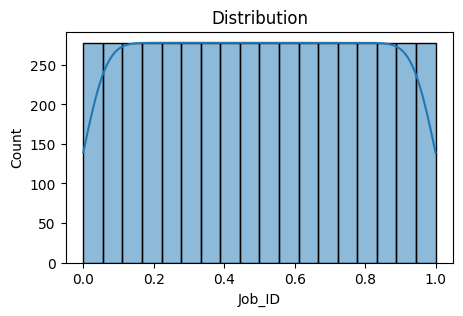

In [77]:
plt.figure(figsize=(5,3))
sns.histplot(df.iloc[:,0], kde=True)
plt.title("Distribution")
plt.show()

In [78]:
print("Final Dataset Shape:", df.shape)

print(df.head())

Final Dataset Shape: (5000, 16)
     Job_ID  Task_Start_Time  Task_End_Time  CPU_Utilization (%)  \
0  0.000000           0.0000         0.0000             0.374594   
1  0.222244           0.0002         0.0002             0.950988   
2  0.444489           0.0004         0.0004             0.732183   
3  0.666733           0.0006         0.0006             0.598775   
4  0.888978           0.0008         0.0008             0.156039   

   Memory_Consumption (MB)  Task_Execution_Time (ms)  \
0                 0.416222                  0.537472   
1                 0.692102                  0.564836   
2                 0.610059                  0.246886   
3                 0.958378                  0.157852   
4                 0.239461                  0.236471   

   System_Throughput (tasks/sec)  Task_Waiting_Time (ms)  Data_Source  \
0                       0.897895                0.073812     0.666667   
1                       0.792632                0.054601     1.000000   
2  